#  EN3160 Assignment_1 on Intensity Transformations and Neighborhood Filtering.

In [1]:
# Task 1
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints, dtype=np.float64)
    xs, ys = breakpoints[:, 0], breakpoints[:, 1]

    lut = np.interp(np.arange(256), xs, ys).astype(np.uint8)
    out = cv.LUT(im, lut)
    return out, lut


In [8]:
def load_image(path, index="not_mentioned", condition=None):
    match condition:
        case True:
            img = cv.imread(path, cv.IMREAD_GRAYSCALE)
        case False:
            img = cv.imread(path)
        case None:
            img = cv.imread(path)

    if img is None:
        raise FileNotFoundError(f"Image not found at {path}")
    return img

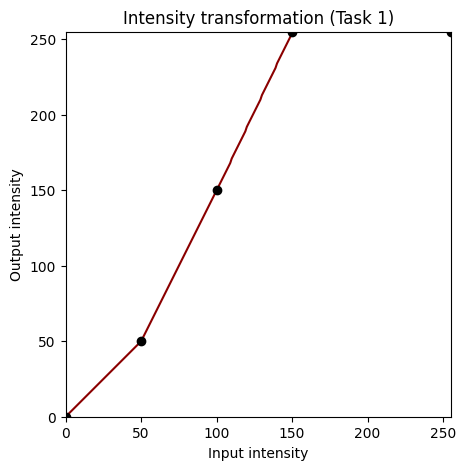

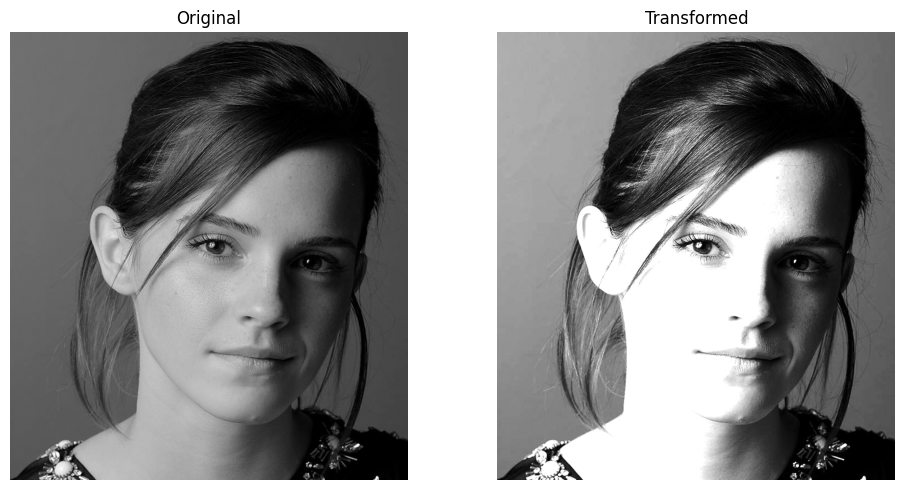

In [4]:
def task_01():
    img = load_image("images/q1.jpeg", True)

    breakpoints = np.array([
        [0,   0],
        [50,  50],
        [100, 150],
        [150, 255],
        [255, 255],
    ])

    out, lut = intensity_transform(img, breakpoints)

    # Plot the transformation curve
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(np.arange(256), lut, color="darkred")
    ax.plot(breakpoints[:, 0], breakpoints[:, 1], "ko")
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 255)
    ax.set_xlabel("Input intensity")
    ax.set_ylabel("Output intensity")
    ax.set_title("Intensity transformation (Task 1)")
    ax.set_aspect("equal")
    plt.savefig("task1_transform_plot.png", dpi=150)
    plt.show()

    # Original vs transformed image
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(out, cmap="gray")
    axes[1].set_title("Transformed")
    axes[1].axis("off")
    plt.tight_layout()
    plt.savefig("task1_before_after.png", dpi=150)
    plt.show()

    cv.imwrite("task1_output.png", out)

task_01()

### Task 02

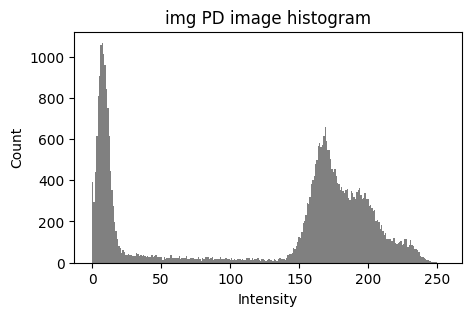

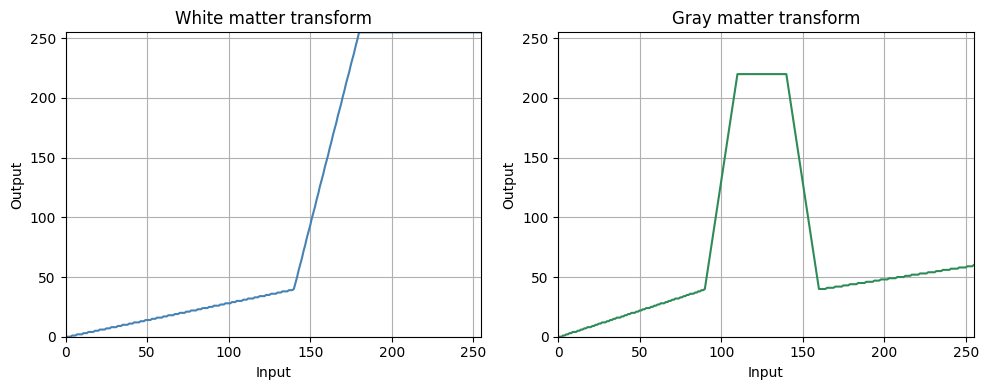

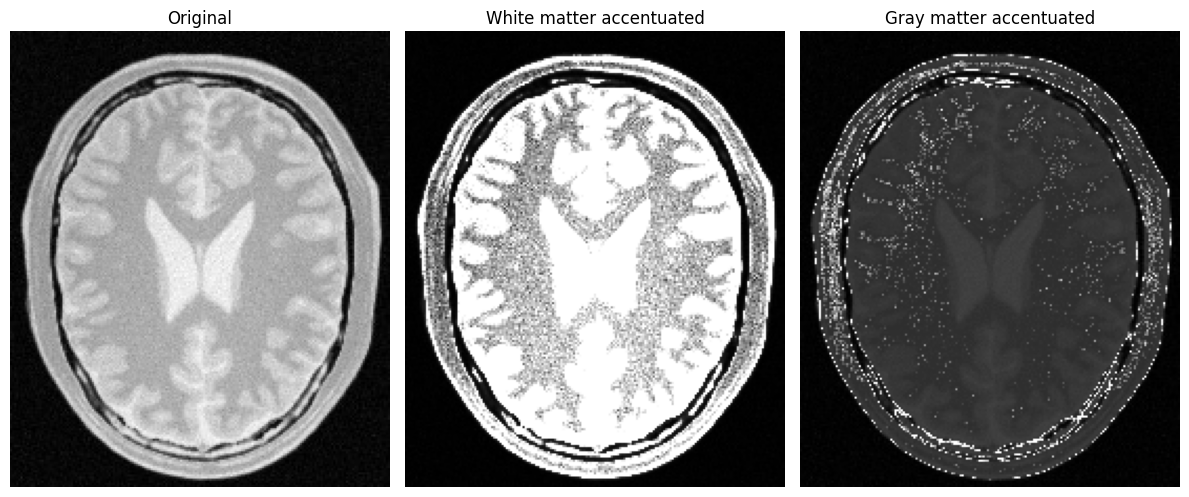

In [5]:
def task_02():
    img = load_image("images/q2.jpeg", True)
    # Inspect the histogram first to choose good breakpoints
    plt.figure(figsize=(5, 3))
    plt.hist(img.ravel(), bins=256, range=(0, 255), color="gray")
    plt.title("img PD image histogram")
    plt.xlabel("Intensity")
    plt.ylabel("Count")
    plt.savefig("task2_histogram.png", dpi=150)
    plt.show()

    # White matter is typically the brightest tissue -> accentuate high intensities
    breakpoints_white = np.array([
        [0,   0],
        [140, 40],
        [180, 255],
        [200, 255],
        [255, 255],
    ])

    # Gray matter occupies a mid-intensity band -> accentuate a narrower mid band
    breakpoints_gray = np.array([
        [0,   0],
        [90,  40],
        [110, 220],
        [140, 220],
        [160, 40],
        [255, 60],
    ])

    white_img, white_lut = intensity_transform(img, breakpoints_white)
    gray_img, gray_lut = intensity_transform(img, breakpoints_gray)

    # Plot both transformation curves
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(white_lut, color="steelblue")
    axes[0].set_title("White matter transform")
    axes[1].plot(gray_lut, color="seagreen")
    axes[1].set_title("Gray matter transform")

    for ax in axes:
        ax.set_xlim(0, 255)
        ax.set_ylim(0, 255)
        ax.set_xlabel("Input")
        ax.set_ylabel("Output")
        ax.grid(True)
        
    plt.tight_layout()
    plt.savefig("task2_transform_curves.png", dpi=150)
    plt.show()

    # Show original, white-accentuated, gray-accentuated images
    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    for ax, im, title in zip(
        axes,
        [img, white_img, gray_img],
        ["Original", "White matter accentuated", "Gray matter accentuated"],
    ):
        ax.imshow(im, cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("task2_results.png", dpi=150)
    plt.show()

    cv.imwrite("task2_white_matter.png", white_img)
    cv.imwrite("task2_gray_matter.png", gray_img)

task_02()

### Task 03


Gamma value used: 0.1


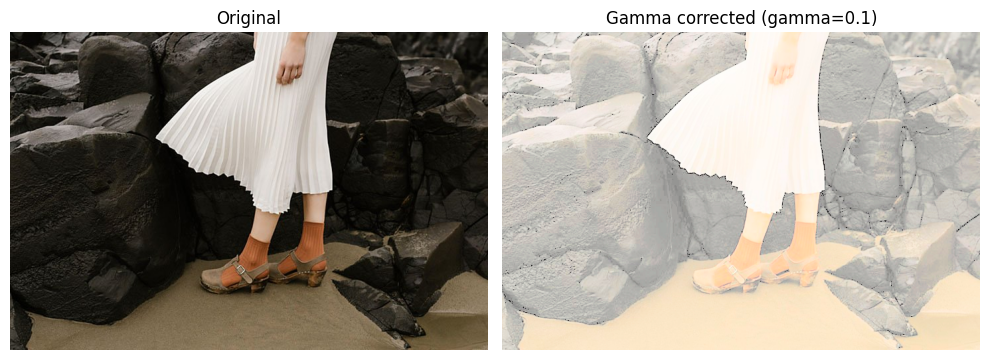

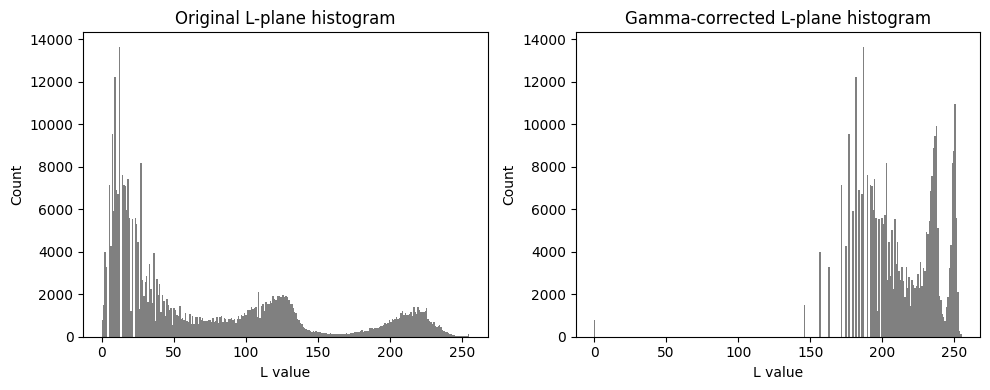

In [11]:
def task_03():
    img= load_image("images/q3.jpeg", False)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
    L, a, b = cv.split(lab)

    gamma = 0.1
    L_norm = L.astype(np.float64) / 255.0
    L_gamma = np.power(L_norm, gamma) * 255.0
    L_gamma = np.clip(L_gamma, 0, 255).astype(np.uint8)

    lab_corrected = cv.merge([L_gamma, a, b])
    img_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)
    img_corrected_rgb = cv.cvtColor(img_corrected, cv.COLOR_BGR2RGB)

    print(f"Gamma value used: {gamma}")

    # Original vs corrected
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(img_corrected_rgb)
    axes[1].set_title(f"Gamma corrected (gamma={gamma})")
    axes[1].axis("off")
    plt.tight_layout()
    plt.savefig("task3_before_after.png", dpi=150)
    plt.show()

    # Histograms of L plane before/after
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(L.ravel(), bins=256, range=(0, 255), color="gray")
    axes[0].set_title("Original L-plane histogram")
    axes[1].hist(L_gamma.ravel(), bins=256, range=(0, 255), color="gray")
    axes[1].set_title("Gamma-corrected L-plane histogram")
    for ax in axes:
        ax.set_xlabel("L value")
        ax.set_ylabel("Count")
    plt.tight_layout()
    plt.savefig("task3_histograms.png", dpi=150)
    plt.show()

    cv.imwrite("task3_output.png", img_corrected)


task_03()